# A toy chain with a circuit-based proof of work

Each block's SHA-256 hash turns into a 4-qubit circuit, and a block counts as valid when that circuit's most likely outcome is |1111>. This adds no security over plain hashing; it is practice at building circuits from data. The code lives in `src/`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from qiskit.visualization import plot_histogram

from src.blockchain import Block, Blockchain
from src.quantum_validator import QuantumValidator

08e07bdd1772867ebb13c563f012a1cc2b2785b02459065cb1b779412007f566


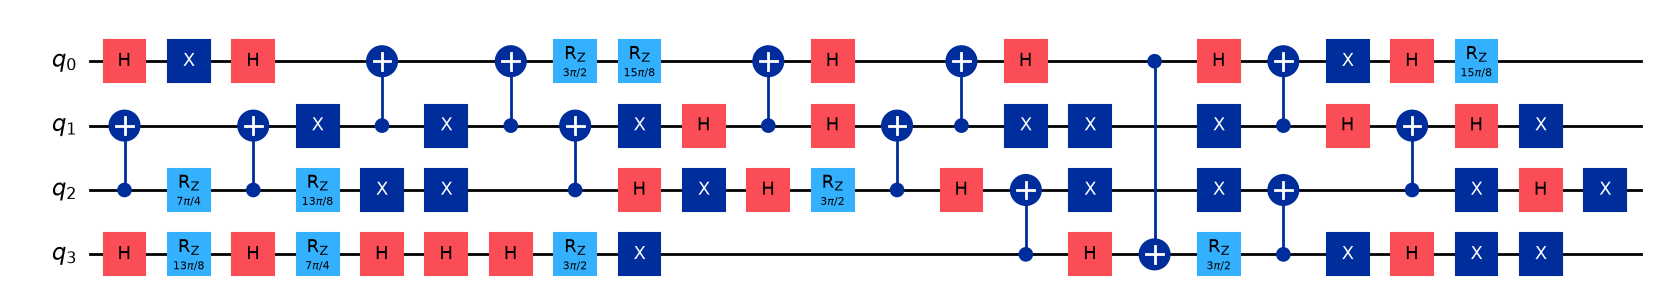

In [2]:
validator = QuantumValidator(num_qubits=4)
block = Block(1, "alice pays bob 5", "0" * 64, timestamp=0.0)
block_hash = block.compute_hash()
print(block_hash)
validator.circuit(block_hash).draw("mpl", fold=40)

valid: False


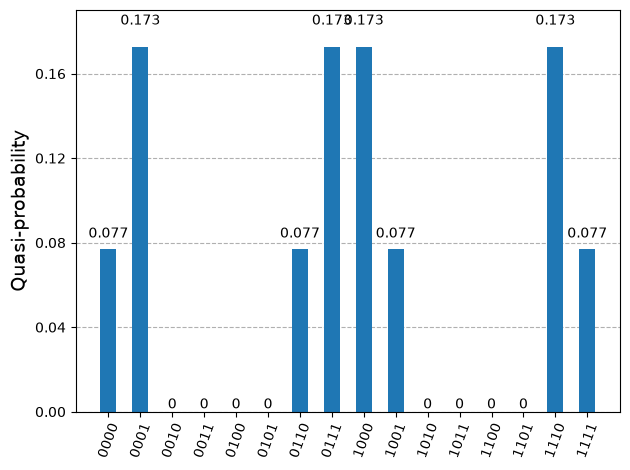

In [3]:
print("valid:", validator.is_valid(block_hash))
plot_histogram(validator.probabilities(block_hash))

## Mining

Mining tries nonces until the hash produces a circuit that favours |1111>.

In [4]:
chain = Blockchain(validator)
for i, data in enumerate(["alice pays bob 5", "bob pays carol 2", "carol pays alice 1"]):
    b = chain.mine(data, timestamp=float(i + 1))
    print(f"block {b.index}: nonce {b.nonce}")
print("chain valid:", chain.is_valid())

block 1: nonce 9


block 2: nonce 231
block 3: nonce 0
chain valid: True


In [5]:
chain.chain[1].data = "alice pays bob 500"
print("after editing block 1, chain valid:", chain.is_valid())

after editing block 1, chain valid: False
